# Práctica — Clasificación y Métodos de Ensamble

## Objetivo

Esta práctica no busca solamente ejecutar código. Busca observar cómo se comportan distintos modelos de clasificación y justificar decisiones como ingenieros.

Vamos a trabajar tres ideas:

1. Los árboles de decisión pueden ser inestables.
2. Random Forest estabiliza combinando muchos árboles.
3. La elección del “mejor” modelo depende de la métrica y del costo del error.

---

## Setup

Ejecutá esta celda primero. Si `xgboost` no está instalado, el notebook usa una alternativa de `scikit-learn` para mantener la práctica funcionando.

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

print("XGBoost disponible:", XGBOOST_AVAILABLE)


XGBoost disponible: True


# Parte A — Experimentar la inestabilidad del árbol

## Concepto

Un árbol de decisión puede cambiar mucho si cambia levemente el dataset.  
Esto es una manifestación de **alta varianza** o **varianza estructural**.

Vamos a entrenar 10 árboles sobre muestras bootstrap del mismo dataset y ver qué pasa con:

- la raíz del árbol
- la predicción de un punto ambiguo

---

In [8]:
# Dataset pequeño de riesgo crediticio
# Ing = ingreso, Deu = deuda, R = riesgo
data = pd.DataFrame({
    "Ingreso": [2, 3, 4, 5, 6, 7, 8, 9, 4, 6],
    "Deuda":   [8, 7, 6, 5, 4, 3, 2, 1, 7, 6],
    "Riesgo":  [1, 1, 1, 0, 0, 0, 0, 0, 1, 1]
})

X = data[["Ingreso", "Deuda"]]
y = data["Riesgo"]

punto_ambiguo = pd.DataFrame({"Ingreso": [6], "Deuda": [6]})

data


,Ingreso,Deuda,Riesgo
0,2,8,1
1,3,7,1
2,4,6,1
3,5,5,0
4,6,4,0
5,7,3,0
6,8,2,0
7,9,1,0
8,4,7,1
9,6,6,1


In [5]:
def entrenar_arboles_bootstrap(X, y, n_modelos=10, random_state=42):
    resultados = []

    for i in range(n_modelos):
        X_boot, y_boot = resample(
            X, y,
            replace=True,
            n_samples=len(X),
            random_state=random_state + i
        )

        tree = DecisionTreeClassifier(max_depth=None, random_state=random_state + i)
        tree.fit(X_boot, y_boot)

        pred = tree.predict(punto_ambiguo)[0]
        root_feature = X.columns[tree.tree_.feature[0]] if tree.tree_.feature[0] != -2 else "Hoja"

        resultados.append({
            "modelo": i + 1,
            "raiz": root_feature,
            "prediccion_punto_ambiguo": pred
        })

    return pd.DataFrame(resultados)

resultados_arboles = entrenar_arboles_bootstrap(X, y)
resultados_arboles


,modelo,raiz,prediccion_punto_ambiguo
0,1,Deuda,1
1,2,Ingreso,0
2,3,Deuda,0
3,4,Deuda,1
4,5,Ingreso,0
5,6,Deuda,0
6,7,Deuda,1
7,8,Ingreso,0
8,9,Ingreso,0
9,10,Deuda,1


Distribución de predicciones:
prediccion_punto_ambiguo
0    6
1    4
Name: count, dtype: int64

Raíces utilizadas:
raiz
Deuda      6
Ingreso    4
Name: count, dtype: int64


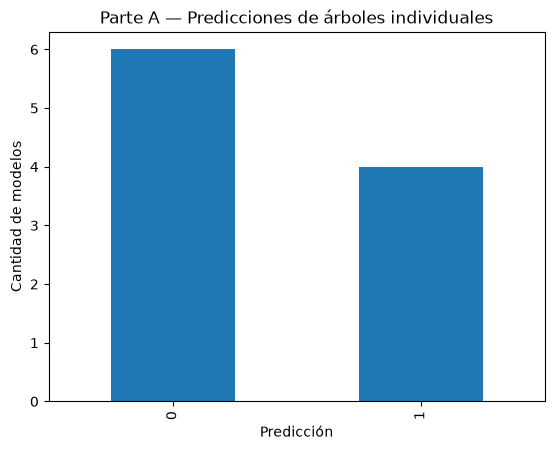

In [6]:
print("Distribución de predicciones:")
print(resultados_arboles["prediccion_punto_ambiguo"].value_counts())

print("\nRaíces utilizadas:")
print(resultados_arboles["raiz"].value_counts())

resultados_arboles["prediccion_punto_ambiguo"].value_counts().plot(kind="bar")
plt.title("Parte A — Predicciones de árboles individuales")
plt.xlabel("Predicción")
plt.ylabel("Cantidad de modelos")
plt.show()


## Reflexión Parte A

Respondé brevemente:

1. ¿Todos los árboles predijeron lo mismo para el punto ambiguo?
2. ¿La raíz del árbol fue siempre la misma?
3. ¿Qué nos dice esto sobre la estabilidad de los árboles individuales?

**Respuesta:**  
1. No, no todos predijeron lo mismo para el punto ambiguo. En los 10 árboles hubo predicciones 0 y 1.

2. No, la raíz del árbol no fue siempre la misma. Aparecieron las raíces Deuda e Ingreso.

3. Esto muestra que un árbol de decisión individual es sensible al muestreo: pequeños cambios en los datos pueden cambiar tanto la primera partición como la predicción final. En este experimento, 6 árboles quedaron con raíz Deuda y 4 con Ingreso; 6 predijeron 0 y 4 predijeron 1.

# Parte B — Observar la estabilización con Random Forest

## Concepto

Random Forest combina muchos árboles.  
La idea no es que cada árbol sea estable, sino que el conjunto sea más estable que cada árbol individual.

---

In [9]:
def entrenar_random_forests_bootstrap(X, y, n_modelos=10, random_state=42):
    resultados = []

    for i in range(n_modelos):
        X_boot, y_boot = resample(
            X, y,
            replace=True,
            n_samples=len(X),
            random_state=random_state + i
        )

        rf = RandomForestClassifier(
            n_estimators=100,
            max_depth=None,
            random_state=random_state + i
        )
        rf.fit(X_boot, y_boot)

        pred = rf.predict(punto_ambiguo)[0]

        resultados.append({
            "modelo": i + 1,
            "prediccion_punto_ambiguo": pred
        })

    return pd.DataFrame(resultados)

resultados_rf = entrenar_random_forests_bootstrap(X, y)
resultados_rf


,modelo,prediccion_punto_ambiguo
0,1,1
1,2,0
2,3,0
3,4,1
4,5,0
5,6,0
6,7,0
7,8,1
8,9,1
9,10,1


Distribución de predicciones — Árboles individuales:
prediccion_punto_ambiguo
0    6
1    4
Name: count, dtype: int64

Distribución de predicciones — Random Forest:
prediccion_punto_ambiguo
1    5
0    5
Name: count, dtype: int64


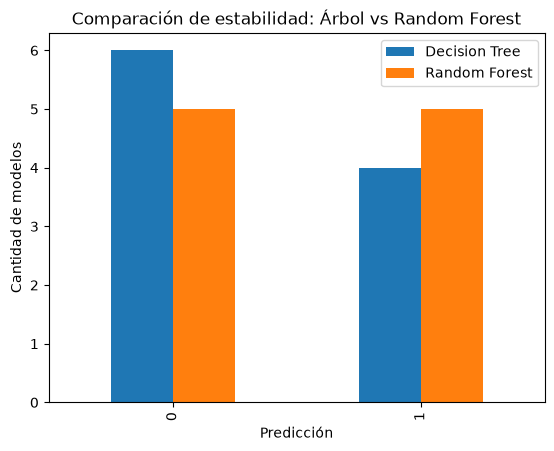

In [10]:
print("Distribución de predicciones — Árboles individuales:")
print(resultados_arboles["prediccion_punto_ambiguo"].value_counts())

print("\nDistribución de predicciones — Random Forest:")
print(resultados_rf["prediccion_punto_ambiguo"].value_counts())

comparacion = pd.DataFrame({
    "Decision Tree": resultados_arboles["prediccion_punto_ambiguo"].value_counts(),
    "Random Forest": resultados_rf["prediccion_punto_ambiguo"].value_counts()
}).fillna(0)

comparacion.plot(kind="bar")
plt.title("Comparación de estabilidad: Árbol vs Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Cantidad de modelos")
plt.show()


## Reflexión Parte B

Respondé brevemente:

1. ¿Random Forest fue más estable que los árboles individuales?
2. ¿Qué cambió entre la Parte A y la Parte B?
3. ¿Por qué promediar modelos puede reducir varianza?

**Respuesta:**  
1. No de forma concluyente en este experimento tan pequeño: los dos enfoques siguieron mostrando variación entre muestras bootstrap. Lo que sí se ve es que Random Forest busca estabilizar la decisión agregando muchos árboles.

2. En la Parte A miramos árboles individuales; en la Parte B miramos el efecto de un ensamble. El árbol individual cambia raíz y predicción con más facilidad, mientras que el ensamble tiende a suavizar esas diferencias.

3. Porque al combinar varios modelos se cancelan parcialmente los errores idiosincráticos de cada árbol. Eso reduce la sensibilidad a pequeñas variaciones del dataset y baja la varianza global.

# Parte C — Tomar decisiones como ingenieros

## Concepto

Ahora vamos a comparar modelos usando métricas de clasificación.

Modelos:

- Decision Tree
- Random Forest
- XGBoost, si está instalado
- Gradient Boosting como alternativa si XGBoost no está disponible

La pregunta no es solo: “¿qué modelo tiene mejor número?”  
La pregunta es: **¿qué modelo elegirías según el costo del error?**

---

## Dataset

Este notebook intenta usar un archivo `titanic.csv` si está en la misma carpeta.

Columnas esperadas, si usás Titanic real:

- `Survived`
- `Pclass`
- `Sex`
- `Age`
- `SibSp`
- `Parch`
- `Fare`
- `Embarked`

Si el archivo no existe, el notebook genera un dataset sintético con estructura similar para que la práctica pueda ejecutarse igual.

In [11]:
from pathlib import Path

def cargar_o_generar_titanic():
    path = Path("titanic.csv")

    if path.exists():
        df = pd.read_csv(path)
        print("Usando titanic.csv local")
        return df

    print("No se encontró titanic.csv. Generando dataset sintético tipo Titanic.")

    n = 900
    rng = np.random.default_rng(RANDOM_STATE)

    pclass = rng.choice([1, 2, 3], size=n, p=[0.24, 0.21, 0.55])
    sex = rng.choice(["male", "female"], size=n, p=[0.62, 0.38])
    age = np.clip(rng.normal(30, 14, size=n), 1, 80)
    fare = np.clip(rng.lognormal(mean=3.0, sigma=0.8, size=n), 5, 250)
    sibsp = rng.poisson(0.5, size=n)
    parch = rng.poisson(0.35, size=n)
    embarked = rng.choice(["S", "C", "Q"], size=n, p=[0.72, 0.18, 0.10])

    # Probabilidad sintética de supervivencia
    logit = (
        -1.2
        + 1.4 * (sex == "female")
        + 0.75 * (pclass == 1)
        + 0.25 * (pclass == 2)
        - 0.018 * age
        + 0.004 * fare
        - 0.15 * sibsp
        - 0.10 * parch
    )

    prob = 1 / (1 + np.exp(-logit))
    survived = rng.binomial(1, prob)

    return pd.DataFrame({
        "Survived": survived,
        "Pclass": pclass,
        "Sex": sex,
        "Age": age,
        "SibSp": sibsp,
        "Parch": parch,
        "Fare": fare,
        "Embarked": embarked
    })

df = cargar_o_generar_titanic()
df.head()


No se encontró titanic.csv. Generando dataset sintético tipo Titanic.


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,61.747019,0,0,9.389303,C
1,0,2,male,15.569962,1,1,17.392654,S
2,0,3,male,30.985868,0,0,28.784938,Q
3,0,3,male,13.533196,1,1,8.965222,C
4,0,1,female,19.113517,0,0,11.472270,C


In [12]:
# Preparación básica
features = ["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare", "Embarked"]
target = "Survived"

df_model = df[features + [target]].copy()
df_model = df_model.dropna()

X = pd.get_dummies(df_model[features], drop_first=True)
y = df_model[target].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Distribución de clases en test:")
print(y_test.value_counts(normalize=True))


Train: (675, 8)
Test: (225, 8)
Distribución de clases en test:
Survived
0    0.724444
1    0.275556
Name: proportion, dtype: float64


In [13]:
# Definición de modelos
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=None, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

if XGBOOST_AVAILABLE:
    models["XGBoost"] = XGBClassifier(
        n_estimators=150,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric="logloss",
        random_state=RANDOM_STATE
    )
else:
    models["Gradient Boosting (fallback)"] = GradientBoostingClassifier(random_state=RANDOM_STATE)

models


{'Decision Tree': DecisionTreeClassifier(random_state=42),
 'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=3, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=150, n_jobs=None,
               num_parallel_tree=None, ...)}

In [14]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test, threshold=0.5):
    modelo.fit(X_train, y_train)

    if hasattr(modelo, "predict_proba"):
        proba = modelo.predict_proba(X_test)[:, 1]
    else:
        proba = modelo.decision_function(X_test)

    y_pred = (proba >= threshold).astype(int)

    return {
        "Modelo": nombre,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, proba)
    }

resultados = []
for nombre, modelo in models.items():
    resultados.append(evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test, threshold=0.5))

resultados_df = pd.DataFrame(resultados).sort_values("AUC", ascending=False)
resultados_df


,Modelo,Threshold,Accuracy,Precision,Recall,F1,AUC
1,Random Forest,0.5,0.706667,0.452381,0.306452,0.365385,0.678508
2,XGBoost,0.5,0.720000,0.484848,0.258065,0.336842,0.671284
0,Decision Tree,0.5,0.648889,0.355932,0.338710,0.347107,0.552790


## Experimento con thresholds

Ahora vamos a ver cómo cambia la decisión al modificar el umbral.

Probamos:

- 0.3
- 0.5
- 0.7

Observá especialmente qué pasa con **precision** y **recall**.

In [15]:
thresholds = [0.3, 0.5, 0.7]

resultados_thresholds = []

for threshold in thresholds:
    for nombre, modelo in models.items():
        resultados_thresholds.append(
            evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test, threshold=threshold)
        )

thresholds_df = pd.DataFrame(resultados_thresholds)
thresholds_df.sort_values(["Modelo", "Threshold"])


,Modelo,Threshold,Accuracy,Precision,Recall,F1,AUC
0,Decision Tree,0.3,0.648889,0.355932,0.338710,0.347107,0.552790
3,Decision Tree,0.5,0.648889,0.355932,0.338710,0.347107,0.552790
6,Decision Tree,0.7,0.648889,0.355932,0.338710,0.347107,0.552790
1,Random Forest,0.3,0.680000,0.444444,0.645161,0.526316,0.678508
4,Random Forest,0.5,0.706667,0.452381,0.306452,0.365385,0.678508
7,Random Forest,0.7,0.711111,0.363636,0.064516,0.109589,0.678508
2,XGBoost,0.3,0.702222,0.466667,0.564516,0.510949,0.671284
5,XGBoost,0.5,0.720000,0.484848,0.258065,0.336842,0.671284
8,XGBoost,0.7,0.728889,0.571429,0.064516,0.115942,0.671284


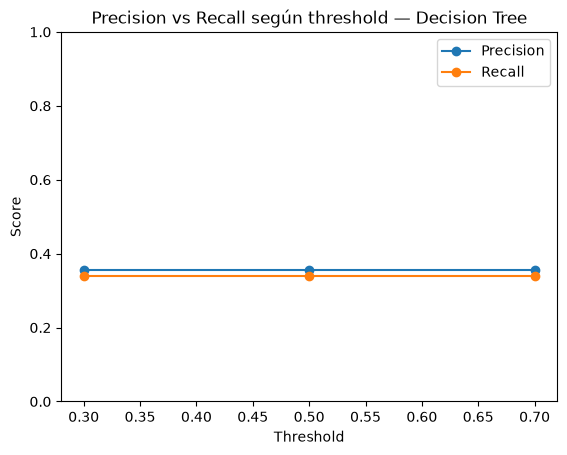

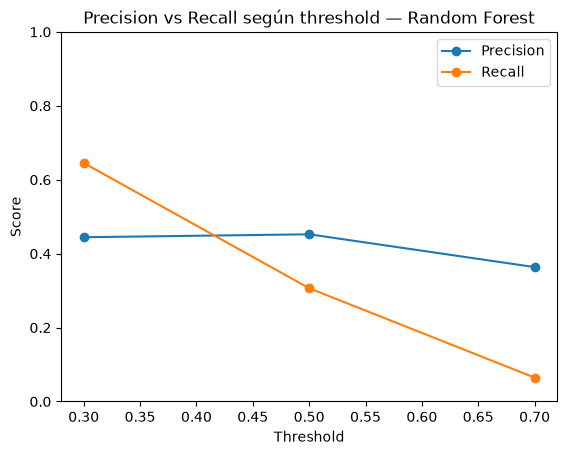

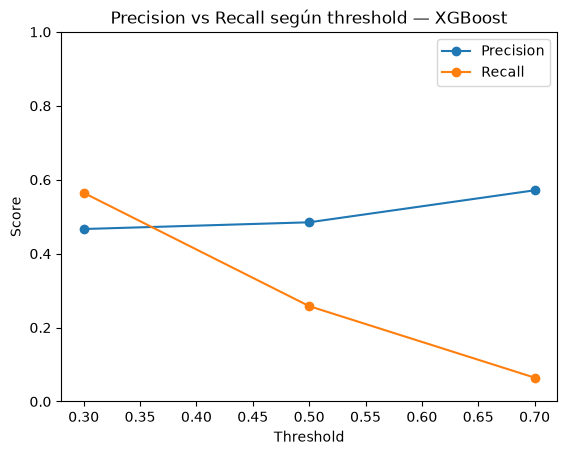

In [16]:
# Visualización simple de Precision y Recall por threshold
for nombre in thresholds_df["Modelo"].unique():
    subset = thresholds_df[thresholds_df["Modelo"] == nombre]

    plt.figure()
    plt.plot(subset["Threshold"], subset["Precision"], marker="o", label="Precision")
    plt.plot(subset["Threshold"], subset["Recall"], marker="o", label="Recall")
    plt.title(f"Precision vs Recall según threshold — {nombre}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.show()


## Escenario 1 — Equipo de rescate

Supongamos que el modelo se usa para priorizar rescates.

**Objetivo:** encontrar a todas las personas vivas.

- Error más grave: Falso Negativo  
- Métrica prioritaria: Recall

### Pregunta

¿Qué modelo y qué threshold elegirías si querés maximizar recall?

Justificá con métricas.

**Respuesta:**  
Elegiría **Random Forest con threshold 0.3**. En este experimento fue el que obtuvo el mejor recall, con **0.645161**, superando a XGBoost en el mismo threshold (**0.564516**) y al árbol de decisión (**0.338710**). Si el objetivo es no dejar personas vivas fuera de rescate, conviene priorizar recall aunque baje la precision.

## Escenario 2 — Uso eficiente de recursos

Supongamos que los recursos de rescate son muy limitados.

**Objetivo:** evitar enviar recursos a objetivos incorrectos.

- Error más grave: Falso Positivo  
- Métrica prioritaria: Precision

### Pregunta

¿Qué modelo y qué threshold elegirías si querés maximizar precision?

Justificá con métricas.

**Respuesta:**  
Elegiría **XGBoost con threshold 0.7**. Fue el mejor en precision, con **0.571429**, por encima de Random Forest (**0.363636**) y del árbol de decisión (**0.355932**) en ese umbral. Si los recursos son escasos, conviene ser más estricto y aceptar menos positivos predichos para reducir falsos positivos.

## Comparación final

Respondé:

1. ¿Elegiste el mismo modelo en ambos escenarios?
2. ¿Elegiste el mismo threshold?
3. ¿Qué métrica fue más útil en cada caso?
4. ¿Qué modelo tuvo mejor AUC?
5. ¿El modelo con mejor AUC fue necesariamente el mejor para cada escenario?

**Respuesta:**  
1. No. Para recall elegí Random Forest; para precision elegí XGBoost.

2. No. Para recall elegí threshold 0.3; para precision elegí threshold 0.7.

3. En el escenario de rescate la métrica más útil fue **recall**; en el escenario de recursos limitados la métrica más útil fue **precision**.

4. El mejor AUC fue de **Random Forest** con **0.678508**.

5. No. El modelo con mejor AUC no fue necesariamente el mejor para cada escenario, porque AUC resume la capacidad de ranking global, pero la decisión operativa depende del threshold y del costo del error en cada contexto.

# Cierre

La práctica muestra tres ideas:

1. Un árbol individual puede ser inestable.
2. Random Forest estabiliza combinando árboles.
3. Elegir un modelo no depende de una sola métrica universal.

## Idea final

> No existe el mejor modelo en abstracto.  
> Existe el mejor modelo para un contexto.
